## Flipkart Product Analysis

Business Problem: 

To analyze how Flipkart optimize pricing, discount and products positioning to increase sales and customer satisfication.

Dataset details :
- Dataset : flipkart_dataset.csv
- Records : ~20000 (between 2015 and 2016)
- Columns : uniq_id, crawl_timestamp, product_url, product_name, product_category_tree, pid, retail_price, discounted_price, image, is_FK_advantage_product, description, product_rating, overall_rating, brand, product_specifications

For the analysis i took the columns :
- brand, product_name, product_category_tree, product_rating, retail_price, discounted_price

The reason for not taking the rest of the column: 
1. uniq_id,product_url, pid, image, is_FK_advantage_product, description, product_specification don't have analytical value for this business problem
2. overall_rating and product_rating has 91% (ie, 18083) missing values, so that why we only took product_rating for basic rating analysis.
3. crawl_timestamp can be taken but that is optional because we are not looking into time-series here.

##### Data Understanding

In [ ]:
#----------------------------------
# 1. import libraries
#----------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#----------------------------------
# 2. load dataset
#----------------------------------
df = pd.read_csv('../data/flipkart_dataset.csv')

In [ ]:
#----------------------------------
# 3. Filtering necessary columns
#----------------------------------
df = df[['brand', 'product_name', 'product_category_tree', 'product_rating', 'retail_price', 'discounted_price']]
df.head()

,brand,product_name,product_category_tree,product_rating,retail_price,discounted_price
0,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",No rating available,999.0,379.0
1,FabHomeDecor,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",No rating available,32157.0,22646.0
2,AW,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",No rating available,999.0,499.0
3,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",No rating available,699.0,267.0
4,Sicons,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",No rating available,220.0,210.0


In [ ]:
#----------------------------------
# 4. Shape of the dataset
#----------------------------------
df.shape

In [ ]:
#----------------------------------
# 5. Overview of the dataset
#----------------------------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  14136 non-null  object 
 1   product_name           20000 non-null  object 
 2   product_category_tree  20000 non-null  object 
 3   product_rating         20000 non-null  object 
 4   retail_price           19922 non-null  float64
 5   discounted_price       19922 non-null  float64
dtypes: float64(2), object(4)
memory usage: 937.6+ KB


- The product_rating should be a numeric value but it is given as object so it should be changed to numeric.
- Durign converting the string will be changed to Nan due to 'errors= coerce'. 

In [ ]:
#----------------------------------
# 6. Checking for missing values
#----------------------------------
df.isnull().sum()

brand                    5864
product_name                0
product_category_tree       0
product_rating              0
retail_price               78
discounted_price           78
dtype: int64

- The retail_price and discounted_price both have 78missing values as they are small amount i removed them but this is not applicable in all situation.
- But the brand has 5864 missing values so we replace that missing values with 'Unknown'.

In [ ]:
#----------------------------------
# 7. Checking for duplicate values
#----------------------------------
df.duplicated().sum()

np.int64(3737)

In [17]:
df.duplicated(subset=['brand', 'product_name', 'retail_price'])

0        False
1        False
2        False
3        False
4        False
         ...  
19995     True
19996     True
19997     True
19998     True
19999     True
Length: 20000, dtype: bool

In [18]:
df[df.duplicated(subset=['brand', 'product_name', 'retail_price'], keep=False)]

,brand,product_name,product_category_tree,product_rating,retail_price,discounted_price
0,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",No rating available,999.0,379.0
1,FabHomeDecor,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",No rating available,32157.0,22646.0
6,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",No rating available,1199.0,479.0
7,FabHomeDecor,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",No rating available,32157.0,22646.0
9,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",No rating available,1199.0,479.0
...,...,...,...,...,...,...
19995,WallDesign,WallDesign Small Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",No rating available,1500.0,730.0
19996,Wallmantra,Wallmantra Large Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",No rating available,1429.0,1143.0
19997,Elite Collection,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",No rating available,1299.0,999.0
19998,Elite Collection,Elite Collection Medium Acrylic Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",No rating available,1499.0,1199.0


- There are duplicate values but can't blindly remove them as the category can be different or other features.
- But for now we will remove them during the cleaning process.

In [ ]:
#----------------------------------
# 8. Data Cleaning
#----------------------------------

# Converting 'product_rating', 'retail_price', and 'discounted_price' to numeric, coercing errors to NaN
df['product_rating'] = pd.to_numeric(df['product_rating'], errors= 'coerce')
df['retail_price']= pd.to_numeric(df['retail_price'], errors='coerce')
df['discounted_price']= pd.to_numeric(df['discounted_price'], errors = 'coerce')

# Removing rows with missing values in critical columns and filling missing brand names with 'Unknown'
df = df[df['retail_price'].notna() & df['discounted_price'].notna()]
df['brand'] = df['brand'].fillna('Unknown')

# Duplicates removed
df = df.drop_duplicates(subset=['brand', 'product_name', 'retail_price', 'discounted_price'])

In [20]:
df.isnull().sum()

brand                        0
product_name                 0
product_category_tree        0
product_rating           14207
retail_price                 0
discounted_price             0
dtype: int64

- The reason why now the product_rating shows 14207 missing values is due to the convertion to Nan.

In [ ]:
#-----------------------------------
# 9. Saving the cleaned dataset
#-----------------------------------
df.to_csv('../data/cleaned_flipkart_dataset.csv', index=False)

#### Exploratory Data Analysis

In [ ]:
#-----------------------------------
# 10. Load the cleaned dataset to verify
#-----------------------------------
df = pd.read_csv('../data/cleaned_flipkart_dataset.csv')
df.head()

,brand,product_name,product_category_tree,product_rating,retail_price,discounted_price
0,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",NaN,999.0,379.0
1,FabHomeDecor,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",NaN,32157.0,22646.0
2,AW,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",NaN,999.0,499.0
3,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",NaN,699.0,267.0
4,Sicons,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",NaN,220.0,210.0


In [ ]:
#-----------------------------------
# 11. Basic statistics of the cleaned dataset
#-----------------------------------
print("Number of Unique Products: ",df['product_name'].nunique())
print("Number of Brands :", df['brand'].nunique())
print("Number of  Categories:", df['product_category_tree'].nunique())

Number of Unique Products:  12626
Number of Brands : 3486
Number of  Categories: 6346


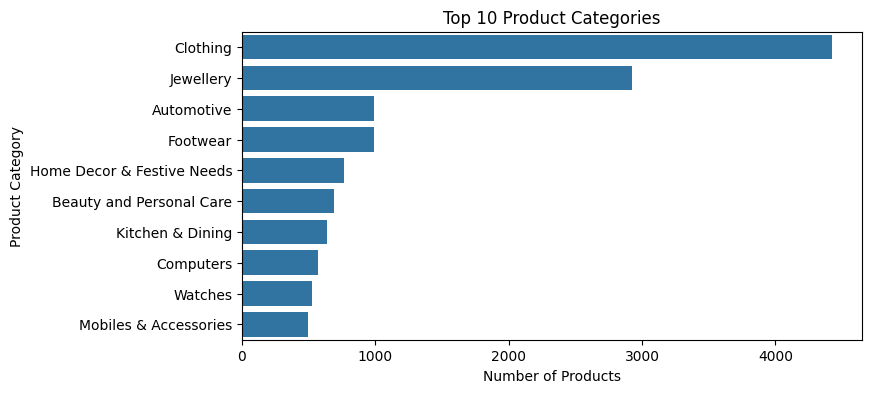

In [ ]:
#-----------------------------------
# 12. Extracting main category and visualizing top categories
#-----------------------------------
df['main_category'] = df['product_category_tree'] \
    .str.replace('[\\[\\]\"]', '', regex=True) \
    .str.split('>>') \
    .str[0] \
    .str.strip()
df['main_category'] = df['main_category'].str.strip()

top_categories = df['main_category'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('Product Category')
plt.show()

- Clothing is the product that customer buy more often from flipkart then after that comes the jewellery.

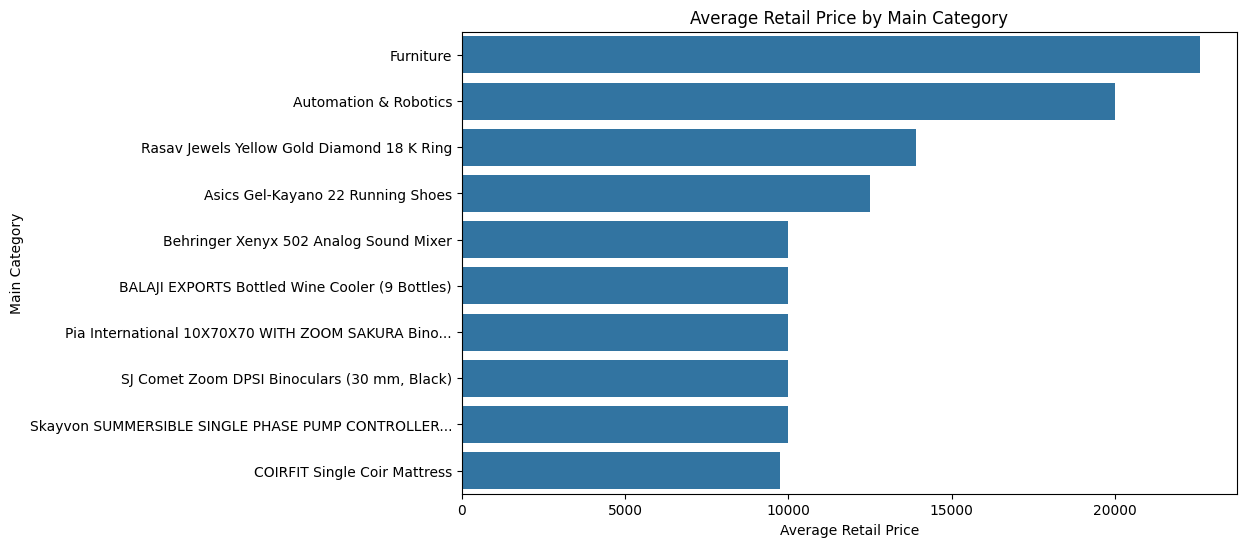

In [ ]:
#-----------------------------------
# 13. Average retail price by main category
#-----------------------------------
category_vs_price = df.groupby('main_category')['retail_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_vs_price.values, y=category_vs_price.index)
plt.title('Average Retail Price by Main Category')
plt.xlabel('Average Retail Price')
plt.ylabel('Main Category')
plt.show()

In [ ]:
#------------------------------------
# 14. Number of products by main category
#------------------------------------
category_vs_products = df.groupby('main_category')['product_name'].nunique().sort_values(ascending=False).head(20)
category_vs_products

main_category
Clothing                      3015
Jewellery                     1951
Automotive                     984
Footwear                       833
Home Decor & Festive Needs     677
Beauty and Personal Care       658
Kitchen & Dining               624
Computers                      564
Watches                        528
Mobiles & Accessories          473
Home Furnishing                402
Toys & School Supplies         283
Pens & Stationery              215
Baby Care                      212
Bags, Wallets & Belts          203
Tools & Hardware               170
Sports & Fitness               162
Furniture                      143
Home Improvement                78
Cameras & Accessories           71
Name: product_name, dtype: int64

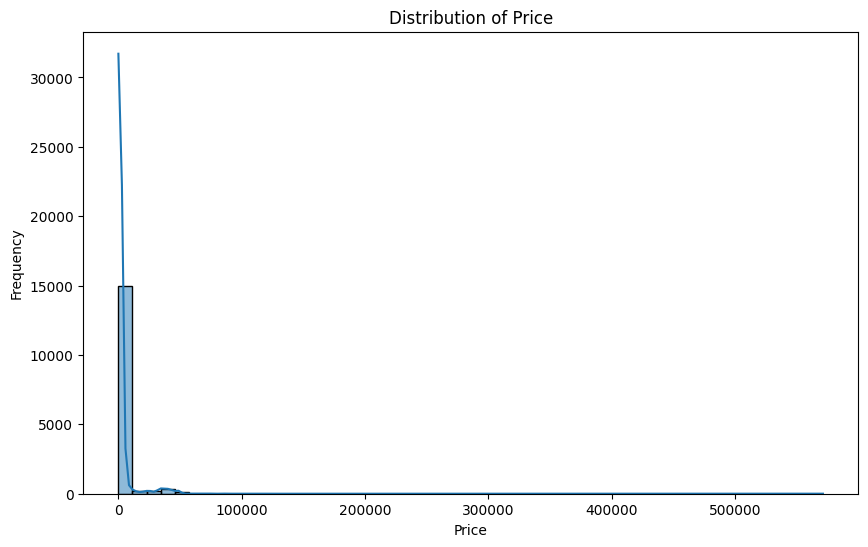

In [ ]:
#------------------------------------
# 15. Distribution of retail prices
#------------------------------------
plt.figure(figsize = (10, 6))

sns.histplot(df['retail_price'], bins=50 , kde = True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- Customers buy things more that are priced low and the things priced high are less purchased.

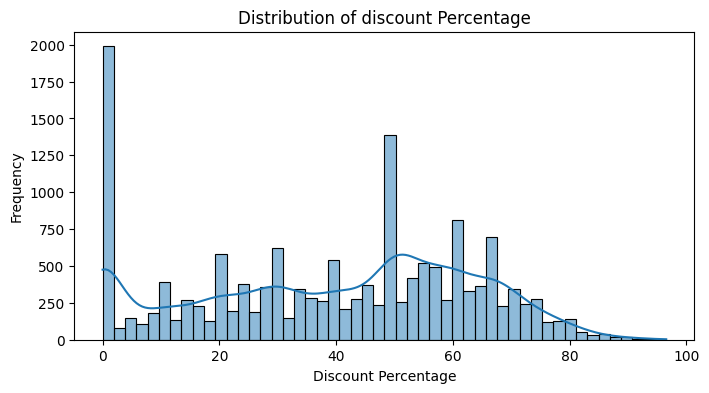

In [ ]:
#---------------------------------
# Discount Analysis
#---------------------------------
df['discount_percentage'] = ((df['retail_price']-df['discounted_price'])/df['retail_price'])*100

plt.figure(figsize=(8, 4))
sns.histplot(df['discount_percentage'], bins=50, kde=True)
plt.title('Distribution of discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.show()

- When the product discount is between middle the customers are more tends to purchase.

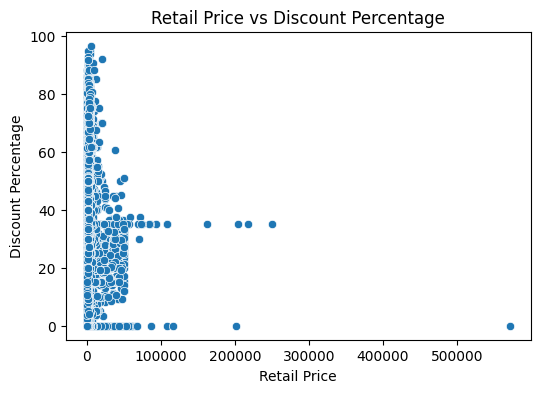

In [ ]:
#---------------------------------
# Discount Percentage vs Retail Price
#---------------------------------
plt.figure(figsize=(6, 4))

sns.scatterplot(x= 'retail_price', y='discount_percentage', data= df)
plt.title('Retail Price vs Discount Percentage')
plt.xlabel('Retail Price')
plt.ylabel('Discount Percentage')
plt.show()

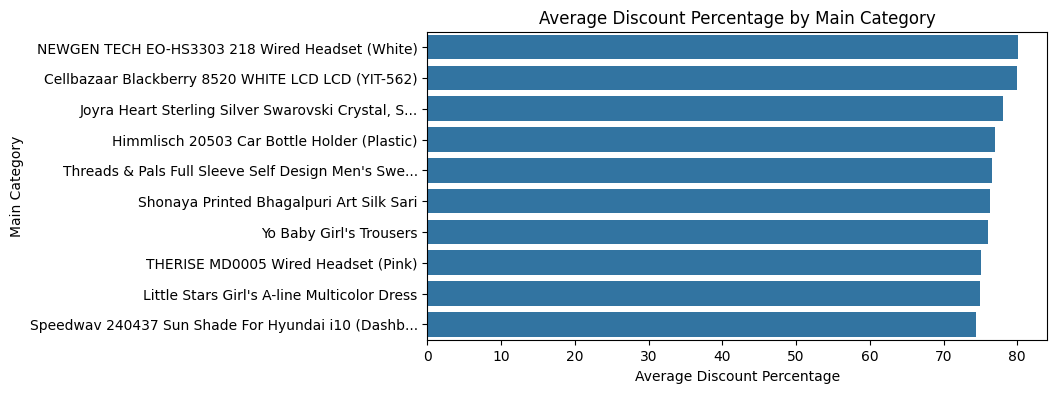

In [43]:
#---------------------------------
# Average Discount Percentage by Main Category
#---------------------------------
discount_by_category = df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=discount_by_category.values, y=discount_by_category.index)
plt.title('Average Discount Percentage by Main Category')
plt.xlabel('Average Discount Percentage')
plt.ylabel('Main Category')
plt.show()

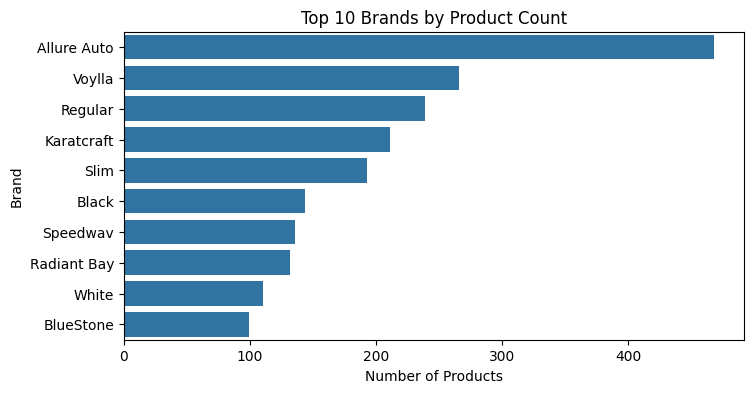

In [ ]:
#---------------------------------
# Brand Analysis
#---------------------------------
df_real = df[~df['brand'].isin(['Unknown', 'Generic'])]
top_brands = df_real['brand'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.show()

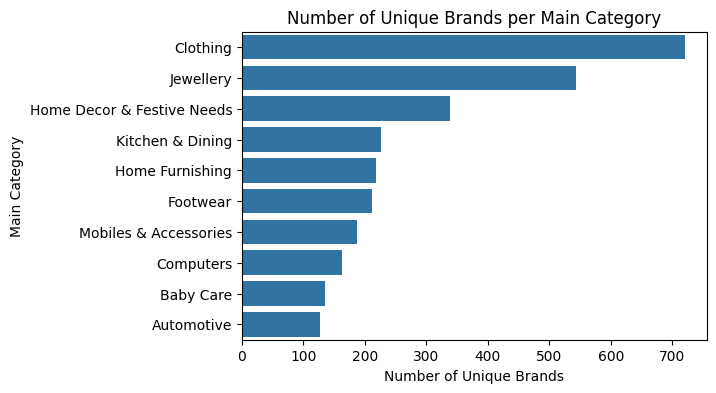

In [ ]:
#---------------------------------
# Number of Unique Brands per Main Category
#---------------------------------
brand_per_category = df_real.groupby('main_category')['brand'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(6, 4))
sns.barplot(x=brand_per_category.values, y=brand_per_category.index)
plt.title('Number of Unique Brands per Main Category') 
plt.xlabel('Number of Unique Brands')
plt.ylabel('Main Category')
plt.show()

- The clothing category has more brands.

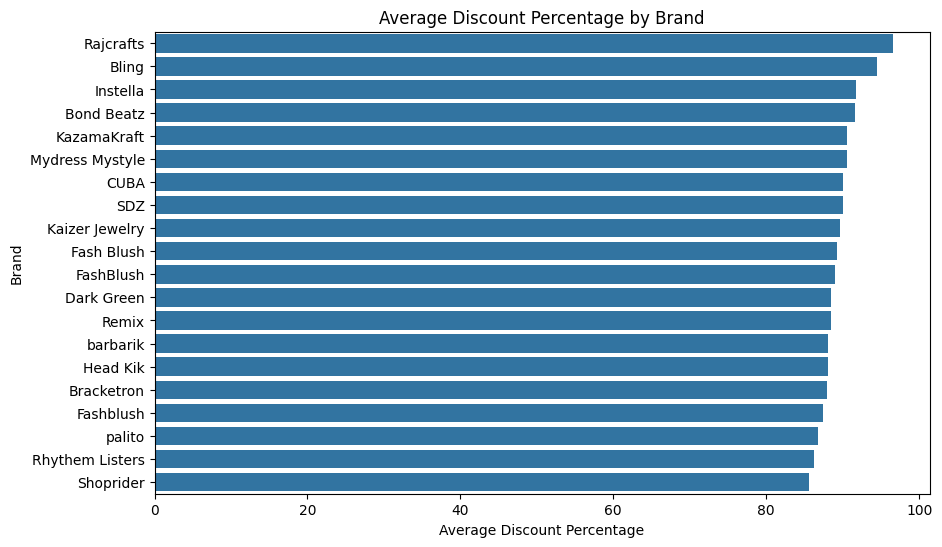

In [ ]:
#---------------------------------
# Average Discount Percentage by Brand
#---------------------------------
discount_by_brand = df_real.groupby('brand')['discount_percentage'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=discount_by_brand.values, y=discount_by_brand.index)
plt.title('Average Discount Percentage by Brand')
plt.xlabel('Average Discount Percentage')
plt.ylabel('Brand')
plt.show()

- Rajcraft offers the highest Discount.

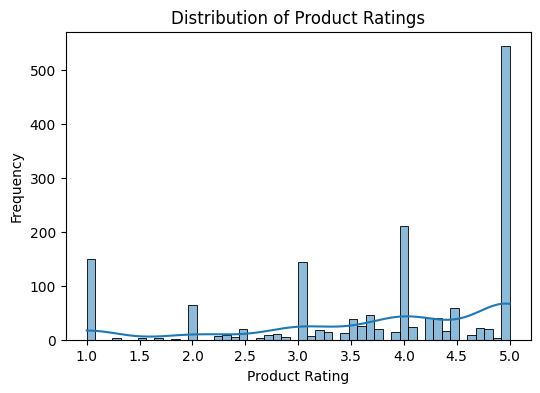

In [ ]:
#---------------------------------
# Rating Analysis
#---------------------------------

plt.figure(figsize=(6, 4))
sns.histplot(df['product_rating'],bins=50, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Product Rating')
plt.ylabel('Frequency')
plt.show()

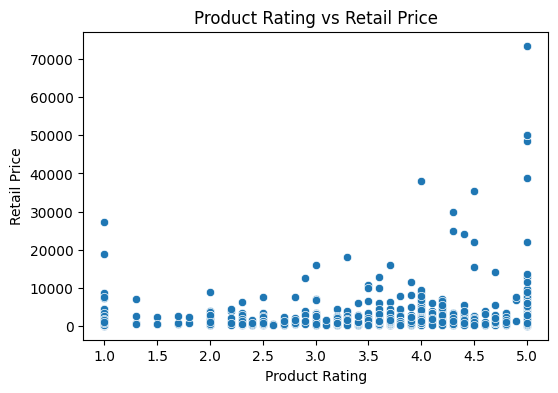

In [ ]:
#---------------------------------
# Product Rating vs Retail Price
#---------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(x='product_rating', y='retail_price', data=df)
plt.title('Product Rating vs Retail Price')
plt.xlabel('Product Rating')
plt.ylabel('Retail Price')
plt.show()

Rating Analysis cannot be taken serious as there are many missing values (`91%) so the charts are unreliable and undpredictable.